In [ ]:
import pandas as pd

df = pd.read_parquet('../data/Processed Positions Data.parquet')

In [ ]:
important_features = ['numMinutes_player', 'assists_player', 'blocks_player', 'steals_player',
       'fieldGoalsMade_player', 'threePointersMade_player',
       'threePointersPercentage_player', 'freeThrowsAttempted_player',
       'freeThrowsPercentage_player', 'reboundsDefensive_player',
       'reboundsOffensive_player', 'reboundsTotal_player', 'turnovers_player',
       'plusMinusPoints_player', 'threePointersAttempted_per36',
       'foulsPersonal_per36', 'season', 'foulsPersonalPercent',
       'fgRelativePercent', 'FTA_rate', 'USG']

df['foulsPersonalPercent'] = df['foulsPersonalPercent'].fillna(df['foulsPersonalPercent'].median())
df.describe()

,personId,gameId,win_player,home_player,numMinutes_player,points_player,assists_player,blocks_player,steals_player,fieldGoalsAttempted_player,...,foulsPersonalPercent,turnoversPercent,fgRelativePercent,3pRelativePercent,ftRelativePercent,3PA_rate,trueShooting,eFG,FTA_rate,USG
count,8.734940e+05,8.734940e+05,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,...,873494.000000,873112.000000,873494.000000,873486.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000
mean,3.071296e+05,2.513569e+07,0.497300,0.498616,26.565203,11.649253,2.605221,0.554347,0.881879,9.435355,...,0.108911,0.107432,-0.004864,-0.143782,-0.249035,0.231896,0.533452,0.496196,0.336332,19.738590
std,5.721478e+05,6.149030e+06,0.499993,0.499998,9.244600,8.039626,2.690828,0.968390,1.060337,5.532100,...,0.068057,0.098008,0.200238,0.290374,0.417261,0.257484,0.214562,0.230338,0.461841,7.347412
min,2.000000e+00,2.000000e+07,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,-0.686000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,1.102607
25%,9.050000e+02,2.100080e+07,0.000000,0.000000,19.000000,6.000000,1.000000,0.000000,0.000000,5.000000,...,0.055556,0.000000,-0.118000,-0.353000,-0.706000,0.000000,0.409836,0.357143,0.000000,14.519445
50%,2.738000e+03,2.200102e+07,0.000000,0.000000,26.090000,10.000000,2.000000,0.000000,1.000000,8.000000,...,0.105263,0.090909,-0.001000,-0.200000,-0.145000,0.166667,0.533049,0.500000,0.227273,19.344221
75%,2.026850e+05,2.910013e+07,1.000000,1.000000,34.000000,16.000000,4.000000,1.000000,1.000000,13.000000,...,0.153846,0.166667,0.108000,0.023000,0.125000,0.400000,0.665680,0.625000,0.500000,24.498526
max,1.643257e+06,6.250000e+07,1.000000,1.000000,69.000000,83.000000,30.000000,15.000000,11.000000,50.000000,...,0.666667,1.000000,0.756000,1.000000,0.737000,1.000000,1.500000,1.500000,17.000000,66.089351


In [ ]:
important_features.remove('season')

# Hyperparameter Tuning on Sample

In [ ]:
sample_seasons = [1980, 1990, 2000, 2010, 2020]
df_tune = df[df['season'].isin(sample_seasons)].copy()
len(df_tune)

In [ ]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

X_tune = df_tune[important_features]
y_tune = df_tune['Position']
position_map = {
    "PG": 0,
    "SG": 1,
    "SF": 2,
    "PF": 3,
    "C": 4
}
y_tune = df_tune['Position'].replace(position_map)

X_train, X_test, y_train, y_test = train_test_split(
    X_tune, y_tune, test_size=0.2,
    stratify=y_tune, random_state=42
)

model = LGBMClassifier(
    objective="multiclass",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "num_leaves": randint(20, 80),
    "max_depth": [-1, 5, 10],
    "learning_rate": uniform(0.03, 0.05),
    "min_child_samples": randint(10, 50)
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc_ovr",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("\nBest CV Score:")
print(search.best_score_)

print("\nBest Parameters:")
print(search.best_params_)

best_model = search.best_estimator_

In [ ]:
position_map = {
    "PG": 0,
    "SG": 1,
    "SF": 2,
    "PF": 3,
    "C": 4
}

In [ ]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from scipy.stats import entropy

seasons = np.sort(df['season'].unique())
auc_hist = []
micro_f1_hist = []
acc_hist = []
f1_class_hist = []
len_hist = []

def compute_oof_proba(X, y, n_splits=5):
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  oof_proba = np.zeros((len(X), 5))
  for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model = LGBMClassifier(
      n_estimators=500,
      learning_rate=0.07849549260809971,
      max_depth=5,
      min_child_samples=47,
      num_leaves=21,
      random_state=42,
      verbose=-1,
      n_jobs=-1
    )
    model.fit(X_train, y_train)
    oof_proba[val_idx] = model.predict_proba(X_val)
  return oof_proba

for season in seasons:
  mask = df['season'] == season
  X = df.loc[mask, important_features]
  y = df.loc[mask, 'Position'].map(position_map).astype(int)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2,
      stratify=y, random_state=42
  )

  model = LGBMClassifier(
      n_estimators=500,
      learning_rate=0.07849549260809971,
      max_depth=5,
      min_child_samples=47,
      num_leaves=21,
      random_state=42,
      verbose=-1,
      n_jobs=-1
  )
  model.fit(X_train, y_train)

  proba = model.predict_proba(X_test)
  preds = model.predict(X_test)
  del model
  auc = roc_auc_score(y_test, proba, multi_class='ovr')
  micro_f1 = f1_score(y_test, preds, average='micro')
  acc = accuracy_score(y_test, preds)
  f1_per_class = f1_score(y_test, preds, average=None, labels=np.arange(5))
  auc_hist.append(auc)
  micro_f1_hist.append(micro_f1)
  acc_hist.append(acc)
  f1_class_hist.append(f1_per_class)
  len_hist.append(len(X))

  # OOF probabilities and entropy
  proba_oof = compute_oof_proba(X, y)
  df.loc[mask, 'positionless_index'] = entropy(proba_oof, axis=1, base=2)
  del proba_oof
  print(f'{season} done. AUC: {auc}. Length: {len(X)}')


1984 done. AUC: 0.7130323127535048. Length: 524
1985 done. AUC: 0.7604922047856588. Length: 1416
1986 done. AUC: 0.8105372767645587. Length: 17742
1987 done. AUC: 0.8167436919219476. Length: 17300
1988 done. AUC: 0.8191730664156707. Length: 17461
1989 done. AUC: 0.8208701981644861. Length: 18562
1990 done. AUC: 0.8148361271154654. Length: 19902
1991 done. AUC: 0.8095455130045204. Length: 19824
1992 done. AUC: 0.8216444152790882. Length: 20002
1993 done. AUC: 0.8112951842176793. Length: 20115
1994 done. AUC: 0.8173355900547599. Length: 20084
1995 done. AUC: 0.8248121226948653. Length: 19986
1996 done. AUC: 0.814454199741875. Length: 20978
1997 done. AUC: 0.8243343469035327. Length: 20648
1998 done. AUC: 0.8308089360759852. Length: 20971
1999 done. AUC: 0.8125305353101402. Length: 13449
2000 done. AUC: 0.8084478792360426. Length: 21643
2001 done. AUC: 0.810553857075065. Length: 21060
2002 done. AUC: 0.8143245006801731. Length: 21081
2003 done. AUC: 0.8000998165773197. Length: 21571
2004 

In [ ]:
seasons = seasons[2:]
auc_hist = auc_hist[2:]
micro_f1_hist = micro_f1_hist[2:]
acc_hist = acc_hist[2:]
f1_class_hist = f1_class_hist[2:]
len_hist = len_hist[2:]

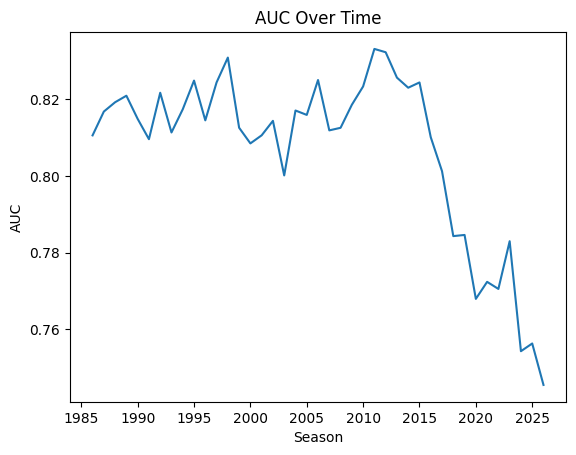

In [ ]:
import matplotlib.pyplot as plt

plt.plot(seasons, auc_hist)
plt.xlabel('Season')
plt.ylabel('AUC')
plt.title('AUC Over Time')
plt.show()

In [ ]:
%pip install ruptures

In [ ]:
import ruptures as rpt

signal = np.array(auc_hist).reshape(-1, 1)

model = rpt.Pelt(model="rbf").fit(signal)
bkps = model.predict(pen=5)   # main tuning knob

change_points = bkps[:-1]
change_years = seasons[change_points]

print(change_years)

for pen in [3, 5, 8, 12]:
    model = rpt.Pelt(model="rbf").fit(signal)
    bkps = model.predict(pen=pen)
    print(pen, seasons[bkps[:-1]])


[2016]
3 [2016]
5 [2016]
8 []
12 []


In [ ]:
from scipy.ndimage import gaussian_filter1d

signal_smooth = gaussian_filter1d(auc_hist, sigma=1).reshape(-1, 1)

model = rpt.Pelt(model="rbf").fit(signal_smooth)
bkps_smooth = model.predict(pen=5)
change_points_smooth = bkps_smooth[:-1]
print(seasons[change_points_smooth])

[2016]


Breakpoint is 2016!

seasons = seasons[2:]
auc_hist = auc_hist[2:]
micro_f1_hist = micro_f1_hist[2:]
acc_hist = acc_hist[2:]
f1_class_hist = f1_class_hist[2:]
len_hist = len_hist[2:]

In [ ]:
df_stats = pd.DataFrame({
    'season': seasons,
    'auc': auc_hist,
    'micro_f1': micro_f1_hist,
    'acc': acc_hist,
    'f1_class': f1_class_hist,
    'len': len_hist
})
df_stats.to_csv('LGBM by Season.csv')

df.to_parquet('Player-Games with Positionless Index.parquet')